In [1]:
import pandas 
import numpy as np
import moments 
import dpluspy 
import scipy
import demesdraw
import demes
from collections import defaultdict

In [2]:
import matplotlib, matplotlib.pylab as plt

plt.rcParams["legend.title_fontsize"] = "small"
matplotlib.rc("xtick", labelsize=8)
matplotlib.rc("ytick", labelsize=8)
matplotlib.rc("axes", labelsize=8)
matplotlib.rc("axes", titlesize=8)
matplotlib.rc("legend", fontsize=8)
plt.rcParams['legend.title_fontsize'] = 'small'

In [3]:
# Load best-fit models and data.
# In models labelled "0", the end time of penultimate Yoruba epoch is pegged to
# the K.San split time; in models labelled "1", to the "OOA" time.

u = 1.3e-8

graph_los0 = "results/model_los0_fit.yaml"
graph_stu0 = "results/model_stu0_fit.yaml"
graph_ust0 = "results/model_ust0_fit.yaml"
graph_los1 = "results/model_los1_fit.yaml"
graph_stu1 = "results/model_stu1_fit.yaml"
graph_ust1 = "results/model_ust1_fit.yaml"

params_los0 = "models/model_los0_params.yaml"
params_stu0 = "models/model_stu0_params.yaml"
params_ust0 = "models/model_ust0_params.yaml"
params_los1 = "models/model_los1_params.yaml"
params_stu1 = "models/model_stu1_params.yaml"
params_ust1 = "models/model_ust1_params.yaml"


data_file = "../../../../analyses/recombination_maps/stats/subset_Bherer.pkl"
data_los = dpluspy.inference.load_bootstrap_reps(
    data_file, graph=graph_los0, return_dict=True)
data_stu = dpluspy.inference.load_bootstrap_reps(
    data_file, graph=graph_stu0, return_dict=True)
data_ust = dpluspy.inference.load_bootstrap_reps(
    data_file, graph=graph_ust0, return_dict=True)

model_los0 = dpluspy.inference.compute_bin_stats(graph_los0, 
    sampled_demes=data_los["pop_ids"], bins=data_los["bins"], u=u)
model_stu0 = dpluspy.inference.compute_bin_stats(graph_stu0, 
    sampled_demes=data_stu["pop_ids"], bins=data_stu["bins"], u=u)
model_ust0 = dpluspy.inference.compute_bin_stats(graph_ust0, 
    sampled_demes=data_ust["pop_ids"], bins=data_ust["bins"], u=u)
model_los1 = dpluspy.inference.compute_bin_stats(graph_los1, 
    sampled_demes=data_los["pop_ids"], bins=data_los["bins"], u=u)
model_stu1 = dpluspy.inference.compute_bin_stats(graph_stu1, 
    sampled_demes=data_stu["pop_ids"], bins=data_stu["bins"], u=u)
model_ust1 = dpluspy.inference.compute_bin_stats(graph_ust1, 
    sampled_demes=data_ust["pop_ids"], bins=data_ust["bins"], u=u)

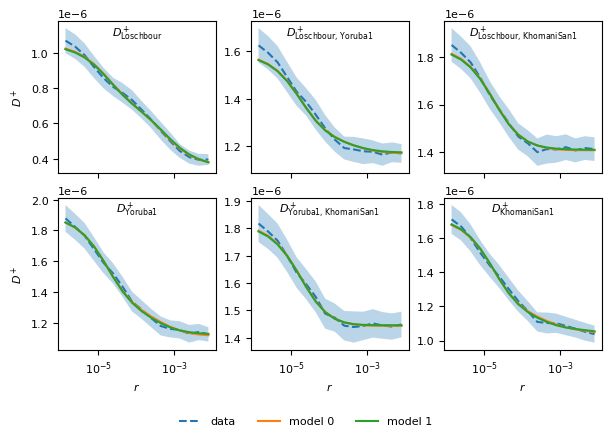

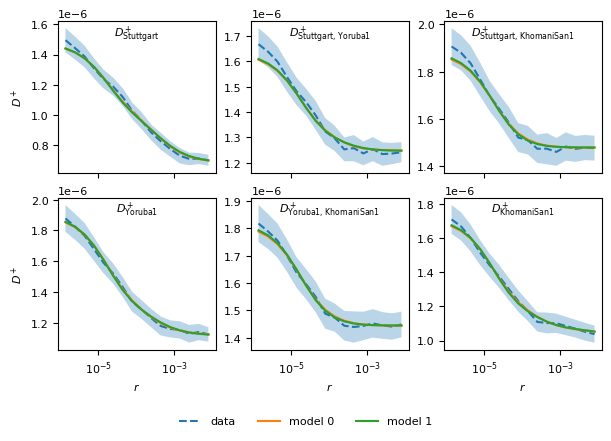

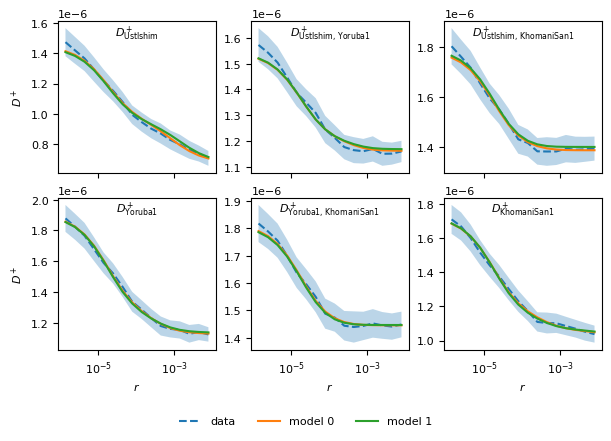

In [5]:
dpluspy.plotting.plot_D_plus_curves(
    models=[model_los0, model_los1],
    pop_ids=data_los["pop_ids"], 
    bins=data_los["bins"], 
    means=data_los["means"], 
    varcovs=data_los["varcovs"], 
    labels=["data", "model 0", "model 1"],
    out="figures/loschbour_model.pdf",
    cols=3
)

dpluspy.plotting.plot_D_plus_curves(
    models=[model_stu0, model_stu1],
    pop_ids=data_stu["pop_ids"], 
    bins=data_stu["bins"], 
    means=data_stu["means"], 
    varcovs=data_stu["varcovs"], 
    labels=["data", "model 0", "model 1"],
    out="figures/stuttgart_model.pdf",
    cols=3
)

dpluspy.plotting.plot_D_plus_curves(
    models=[model_ust0, model_ust1],
    pop_ids=data_ust["pop_ids"], 
    bins=data_ust["bins"], 
    means=data_ust["means"], 
    varcovs=data_ust["varcovs"], 
    labels=["data", "model 0", "model 1"],
    out="figures/ust_ishim_model.pdf",
    cols=3
)

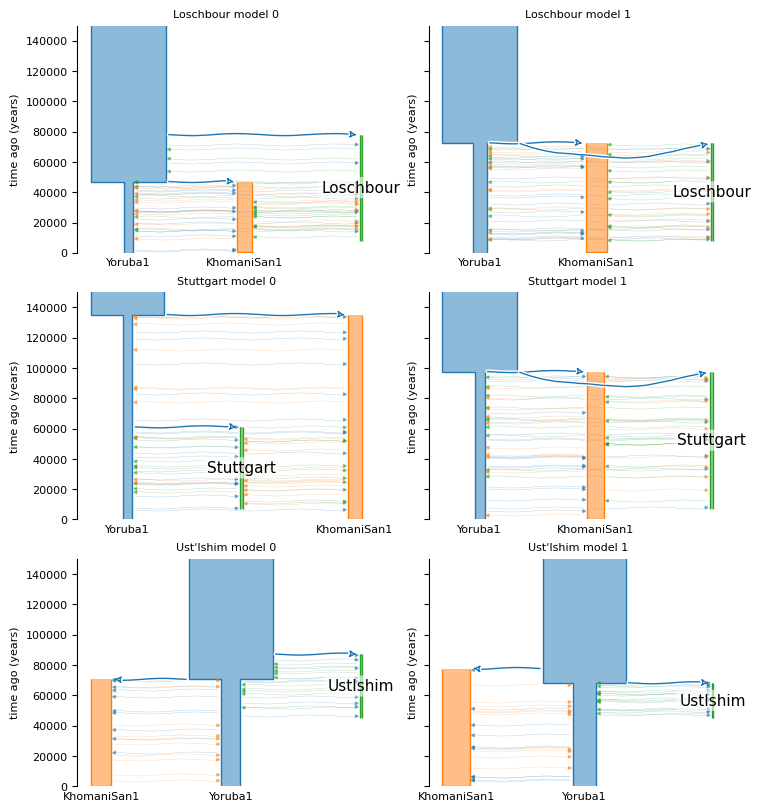

In [8]:
fig, axs = plt.subplots(
    3, 2, figsize=(7.5, 8), layout="constrained", sharey=True)
axs = axs.flat

demesdraw.tubes(demes.load(graph_los0), ax=axs[0])
axs[0].set_title("Loschbour model 0")
demesdraw.tubes(demes.load(graph_los1), ax=axs[1])
axs[1].set_title("Loschbour model 1")

demesdraw.tubes(demes.load(graph_stu0), ax=axs[2], )
axs[2].set_title("Stuttgart model 0")
demesdraw.tubes(demes.load(graph_stu1), ax=axs[3])
axs[3].set_title("Stuttgart model 1")

demesdraw.tubes(demes.load(graph_ust0), ax=axs[4])
axs[4].set_title("Ust'Ishim model 0")
demesdraw.tubes(demes.load(graph_ust1), ax=axs[5])
axs[5].set_title("Ust'Ishim model 1")

axs[5].set_ylim(0, 1.5e5)

plt.savefig("figures/models.pdf")

In [13]:

graph_file = graph_stu0
param_file = params_stu0
data = data_stu

pnames, pvals, uncerts = dpluspy.uncerts.GIM_uncerts(
    graph_file,
    param_file,
    data["means"],
    data["varcovs"],
    bootreps=data["replicates"],
    pop_ids=data["pop_ids"],
    bins=data["bins"],
    u=1.3e-8,
    verbose=False
)

for name, p, u in zip(pnames, pvals, uncerts):
    print(f"{name}\t{p - 1.96 * u:.4}\t{p + 1.96 * u:.4}")

T_KhoYor	3.783e+04	2.328e+05
T_X	1.211e+04	1.102e+05
N_Anc	1.417e+04	1.557e+04
N_AMH	3.375e+04	7.867e+04
N_Yor	4.606e+03	9.99e+03
N_X	1.682e+03	2.855e+03
N_Kho	6.927e+03	1.412e+04
N_KhoBot	18.82	48.36
m_XYor	-4.292e-05	0.0002721
m_KhoYor	6.233e-05	0.0001643
m_KhoX	-1.829e-05	4.466e-05


In [ ]:
# From an older set of models

pdict = defaultdict(list)
for lineage in ["ust", "stu", "los"]:
    data = dpluspy.inference.load_bootstrap_reps(
        data_file, graph=f"results/model_{lineage}_fit.yaml", return_dict=True)
    pnames, pvals, uncerts = dpluspy.uncerts.GIM_uncerts(
        f"results/model_{lineage}_fit.yaml",
        f"models/model_{lineage}_params.yaml",
        data["means"],
        data["varcovs"],
        bootreps=data["replicates"],
        pop_ids=data["pop_ids"],
        bins=data["bins"],
        u=1.3e-8,
    )
    pdict["row"].append(f"{lineage}_mle")
    for pname, pval in zip(pnames, pvals):
        pdict[pname].append(pval)
    pdict["row"].append(f"{lineage}_uncerts")
    for pname, uncert in zip(pnames, uncerts):
        pdict[pname].append(uncert)
df = pandas.DataFrame(pdict)

[30-07-25 11:07:07] Evaluated Hessian element (0, 0)
[30-07-25 11:07:07] Evaluated Hessian element (0, 1)
[30-07-25 11:07:07] Evaluated Hessian element (0, 2)
[30-07-25 11:07:08] Evaluated Hessian element (0, 3)
[30-07-25 11:07:09] Evaluated Hessian element (0, 4)
[30-07-25 11:07:10] Evaluated Hessian element (0, 5)
[30-07-25 11:07:11] Evaluated Hessian element (0, 6)
[30-07-25 11:07:12] Evaluated Hessian element (0, 7)
[30-07-25 11:07:13] Evaluated Hessian element (0, 8)
[30-07-25 11:07:14] Evaluated Hessian element (0, 9)
[30-07-25 11:07:15] Evaluated Hessian element (0, 10)
[30-07-25 11:07:16] Evaluated Hessian element (1, 1)
[30-07-25 11:07:17] Evaluated Hessian element (1, 2)
[30-07-25 11:07:18] Evaluated Hessian element (1, 3)
[30-07-25 11:07:19] Evaluated Hessian element (1, 4)
[30-07-25 11:07:20] Evaluated Hessian element (1, 5)
[30-07-25 11:07:21] Evaluated Hessian element (1, 6)
[30-07-25 11:07:22] Evaluated Hessian element (1, 7)
[30-07-25 11:07:23] Evaluated Hessian element

In [19]:
df.to_csv("uncerts_tbl.csv", index=False)

In [20]:
print(df)

           row      T_KhoYor           T_X         N_Anc         N_AMH  \
0      ust_mle  91218.126426  91218.126425  14971.483660  45616.279964   
1  ust_uncerts  15758.801509  16770.824444    387.341348   4555.035542   
2      stu_mle  99999.546699  63911.254457  15069.571146  48657.621228   
3  stu_uncerts    301.097450  35860.713914    391.676271   3049.087783   
4      los_mle  89185.490880  58785.946983  15038.409814  43655.040153   
5  los_uncerts  20117.219068  12958.937457    387.744588   4910.415483   

          N_Yor          N_X         N_Kho   N_KhoBot    m_XYor  m_KhoYor  \
0  10344.016953   965.729931  11287.978979  41.091871  0.000583  0.000047   
1   1341.718207   283.449918   2167.795023  10.942841  0.000156  0.000028   
2   6550.449453  2109.505288  10561.561911  32.826364  0.000153  0.000108   
3   1172.743674   283.828493   1654.612934   7.406637  0.000080  0.000030   
4   8677.338623   884.814238  12530.061005  37.826242  0.000146  0.000045   
5   1688.386466   1